In [ ]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)


In [2]:
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]
criterion = torch.nn.CrossEntropyLoss()
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
full_dataloader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

In [3]:
def get_gradient_vector(model, dataloader, num_batches=1):
    """Helper to extract the flattened gradient vector from a model."""
    model.zero_grad()
    device = next(model.parameters()).device
    
    # Accumulate gradients over the specified number of batches
    for i, (X, y) in enumerate(dataloader):
        if i >= num_batches: break
        X, y = X.to(device), y.to(device)
        loss = criterion(model(X), y)
        loss.backward()
        
    # Flatten all gradients into a single 1D vector
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1))
    return torch.cat(grads)

In [ ]:
import torch.optim as optim

# 1. Set up the SGD optimizer
# Use a "hot" temperature to ensure you land in a wide, flat valley
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

print("Phase 1: Training the model to reach the local minimum...")

trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim, 
    lr=learning_rate, 
    batch_size=64, 
    epochs=200,
    seed=SEED,
)

print("Training complete. The model is now in the diffusion phase.")


Phase 1: Training the model to reach the local minimum...
Epoch [100/200] | Loss: 0.0000 | Temp (lr/B): 0.00016
Epoch [200/200] | Loss: 0.0000 | Temp (lr/B): 0.00016
Training complete. The model is now in the diffusion phase.


In [5]:
print("Calculating Full-Batch True Gradient...")
true_grad = get_gradient_vector(trained_model, full_dataloader, num_batches=1)

print("Sampling Mini-Batch Gradients...")
num_samples = 500
noise_samples = []

# We will track the noise of a single, randomly chosen parameter (e.g., index 420)
# tracking the whole 14,218-dim vector 500 times takes too much memory!
param_index_to_track = 100 

for i in range(num_samples):
    # Get the gradient for just ONE mini-batch
    mini_grad = get_gradient_vector(trained_model, dataloader, num_batches=1)
    
    # V_k = (Mini-batch Grad) - (True Grad)
    # Note: In the thesis you defined V_k as True - Mini. Either way works, it's centered at 0!
    noise_vector = mini_grad - true_grad 
    
    # Store the noise for our specific parameter
    noise_samples.append(noise_vector[param_index_to_track].item())

noise_samples = np.array(noise_samples)
print("Noise sampling complete!")

Calculating Full-Batch True Gradient...
Sampling Mini-Batch Gradients...
Noise sampling complete!


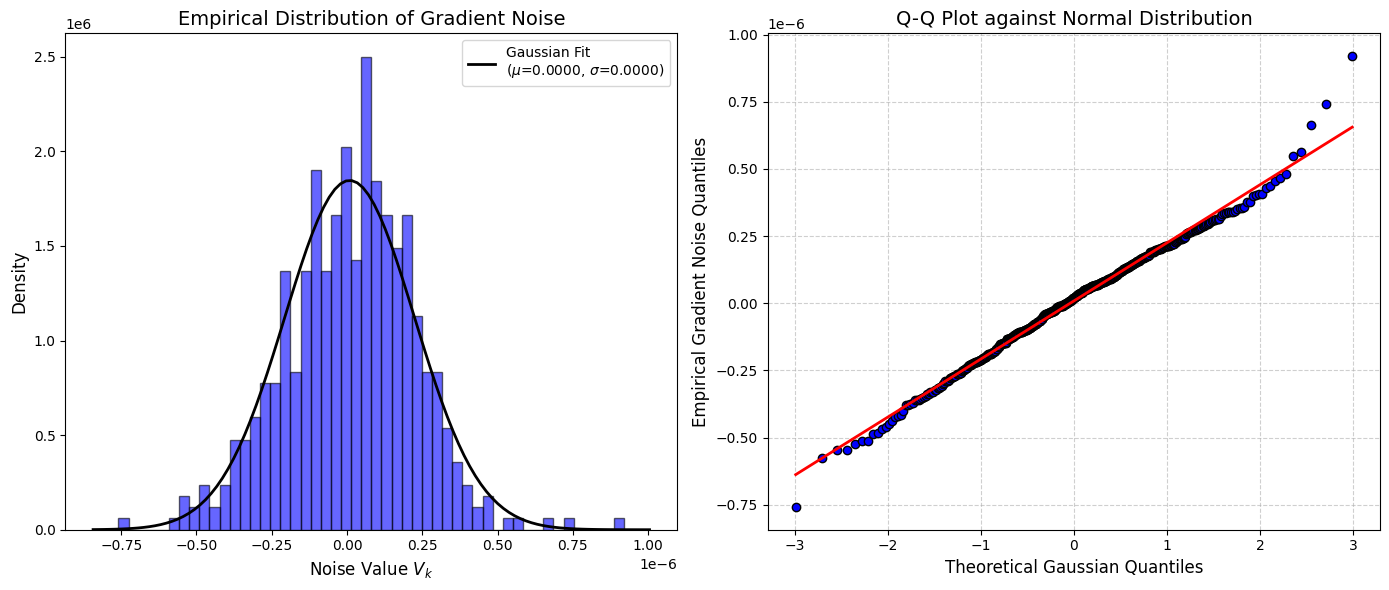

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Histogram with a Gaussian Fit
counts, bins, _ = ax1.hist(noise_samples, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black')
mu, std = stats.norm.fit(noise_samples)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax1.plot(x, p, 'k', linewidth=2, label=f'Gaussian Fit\n($\mu$={mu:.4f}, $\sigma$={std:.4f})')

ax1.set_title("Empirical Distribution of Gradient Noise", fontsize=14)
ax1.set_xlabel("Noise Value $V_k$", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.legend()

# Plot 2: The Q-Q Plot (The definitive proof)
stats.probplot(noise_samples, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('blue')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.get_lines()[1].set_color('red') # The theoretical Gaussian line
ax2.get_lines()[1].set_linewidth(2)

ax2.set_title("Q-Q Plot against Normal Distribution", fontsize=14)
ax2.set_xlabel("Theoretical Gaussian Quantiles", fontsize=12)
ax2.set_ylabel("Empirical Gradient Noise Quantiles", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Gradient_Noise_Gaussianity_Test.png", dpi=300)
plt.show()

Sampling Mini-Batch Gradients for ALL weights...
Normalizing variances across all dimensions...
Plotting the Universal Q-Q Plot...


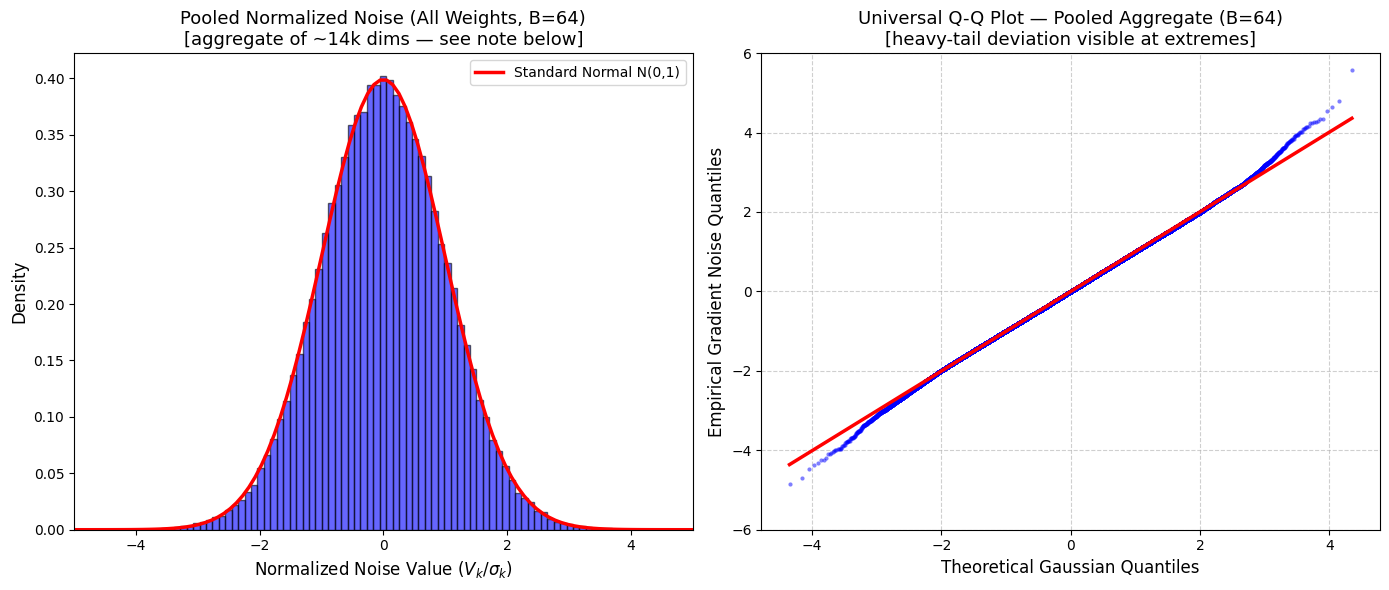

In [8]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ... (Assume true_grad and dataloaders are defined as before) ...

print("Sampling Mini-Batch Gradients for ALL weights...")
num_samples = 500
all_noise_samples = []

for i in range(num_samples):
    mini_grad = get_gradient_vector(trained_model, dataloader, num_batches=1)
    
    # Calculate noise for the entire 14,218-dimensional vector
    # Ensure gradients are detached and moved to CPU numpy arrays
    noise_vector = (mini_grad - true_grad).detach().cpu().numpy()
    all_noise_samples.append(noise_vector)

# Convert to a 2D numpy array of shape (500, 14218)
all_noise_samples = np.array(all_noise_samples)

print("Normalizing variances across all dimensions...")
# Calculate the standard deviation of noise for EACH individual parameter across the 500 steps
stds = np.std(all_noise_samples, axis=0)

# Safety check: avoid division by zero for parameters that might have 0 variance
stds[stds == 0] = 1.0

# Normalize each parameter's noise by its own standard deviation
# This forces every parameter to have a variance of 1.0, allowing us to safely pool them!
normalized_noise = all_noise_samples / stds

# Flatten the entire (500, 14218) matrix into a single 7.1 million-item 1D array
pooled_normalized_noise = normalized_noise.flatten()

print("Plotting the Universal Q-Q Plot...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Histogram (using a subset for faster plotting if 7M points is too slow)
plot_subset = np.random.choice(pooled_normalized_noise, size=100000, replace=False)
ax1.hist(plot_subset, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')

x = np.linspace(-5, 5, 100)
p = stats.norm.pdf(x, 0, 1) # We compare to N(0,1) because we normalized it!
ax1.plot(x, p, 'r', linewidth=2.5, label='Standard Normal N(0,1)')

ax1.set_title("Pooled Normalized Noise (All Weights, B=64)\n[aggregate of ~14k dims — see note below]", fontsize=13)
ax1.set_xlabel("Normalized Noise Value $(V_k / \sigma_k)$", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.set_xlim(-5, 5)
ax1.legend()

# Plot 2: Q-Q Plot
stats.probplot(plot_subset, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('blue')
ax2.get_lines()[0].set_markeredgecolor('none')
ax2.get_lines()[0].set_markersize(3)
ax2.get_lines()[0].set_alpha(0.5)
ax2.get_lines()[1].set_color('red') 
ax2.get_lines()[1].set_linewidth(2.5)

ax2.set_title("Universal Q-Q Plot — Pooled Aggregate (B=64)\n[heavy-tail deviation visible at extremes]", fontsize=13)
ax2.set_xlabel("Theoretical Gaussian Quantiles", fontsize=12)
ax2.set_ylabel("Empirical Gradient Noise Quantiles", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_ylim(-6, 6)

plt.tight_layout()
plt.savefig("Universal_Gradient_Noise_Gaussianity.png", dpi=300)
plt.show()


### Why larger batch sizes produce more Gaussian gradient noise — the CLT argument

The mini-batch gradient for parameter $i$ is the **average** of $B$ independent per-sample gradients:

$$\bar{g}_B^{(i)} = \frac{1}{B} \sum_{j=1}^{B} g_j^{(i)}$$

The gradient noise is the deviation of this average from the true (full-batch) mean $\mu^{(i)}$:

$$V_B^{(i)} = \bar{g}_B^{(i)} - \mu^{(i)} = \frac{1}{B} \sum_{j=1}^{B} \bigl(g_j^{(i)} - \mu^{(i)}\bigr)$$

This is exactly the setting of the **Central Limit Theorem**: a sum of $B$ i.i.d. zero-mean random variables, divided by $B$.  
The CLT guarantees that as $B$ grows, $V_B^{(i)}$ converges in distribution to a Gaussian — **regardless of how heavy-tailed the individual per-sample contributions** $g_j^{(i)} - \mu^{(i)}$ **are**:

$$\sqrt{B} \cdot V_B^{(i)} \xrightarrow{d} \mathcal{N}(0,\, \sigma_i^2) \quad \text{as } B \to \infty$$

| Batch size $B$ | # terms averaged | Tail behaviour |
|---|---|---|
| Small (e.g. 16) | Few — heavy tails survive | Non-Gaussian per dimension |
| Large (e.g. 1024) | Many — tails cancel out | Approximately Gaussian per dimension |

**Intuition:** at $B = 16$ you are averaging only 16 per-sample gradients. If any single sample has an unusually large gradient (a heavy-tailed event), it shifts the mini-batch average significantly. At $B = 1024$ you average 1024 samples; extreme values are diluted by the remaining 1023 terms and the distribution tightens toward a bell curve.

**This is the core result of Wu et al. (2021):** the gradient noise transitions from heavy-tailed to Gaussian as $B$ increases, and the Shapiro-Wilk percentage directly tracks how far along that convergence each batch size is.

---

*Note on the pooled plot above:* normalising by $\sigma_k$ and pooling all ~14 000 dimensions adds a **second** averaging step (across dimensions), which makes even the $B = 64$ aggregate look near-Gaussian. That is why the per-dimension Shapiro-Wilk test (cell below) is more sensitive — it bypasses this pooling effect.


--- Wu et al. (2021) Methodology: Percentage of Gaussianity ---
FAST_MODE=False | samples/B=500 | params=1000

Building noise_dict from mini-batch gradients...
  [Sampling] B=  16 -> shape (500, 14218)  (0.6s)
  [Sampling] B=  64 -> shape (500, 14218)  (0.7s)
  [Sampling] B= 256 -> shape (500, 14218)  (1.4s)
  [Sampling] B=1024 -> shape (500, 14218)  (5.0s)
noise_dict built in 7.7s total.
[Shapiro] B=  16 | % Gaussian: 21.5%  (0.08s)
[Shapiro] B=  64 | % Gaussian: 57.0%  (0.06s)
[Shapiro] B= 256 | % Gaussian: 81.4%  (0.06s)
[Shapiro] B=1024 | % Gaussian: 92.0%  (0.07s)


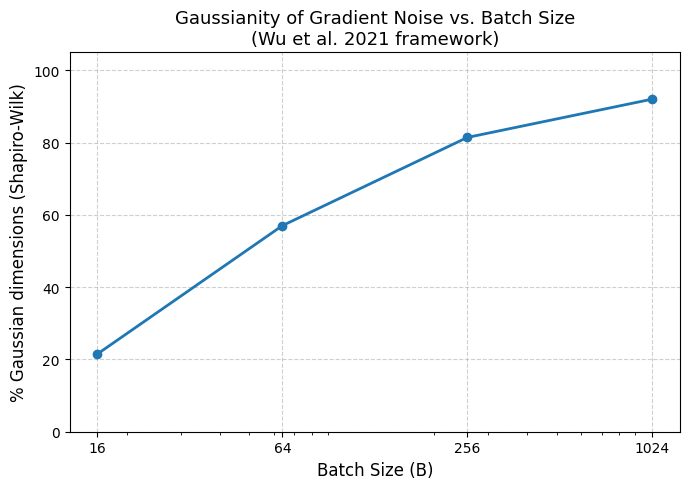

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import time

# --- Fast-mode settings ---
FAST_MODE = False
batch_sizes_to_test = [16, 64, 256] if FAST_MODE else [16, 64, 256, 1024]
num_samples_per_B   = 120           if FAST_MODE else 500
max_params_to_test  = 200           if FAST_MODE else 1000
p_value_threshold   = 0.05
rng = np.random.default_rng(42)

print("--- Wu et al. (2021) Methodology: Percentage of Gaussianity ---")
print(f"FAST_MODE={FAST_MODE} | samples/B={num_samples_per_B} | params={max_params_to_test}")

# ── Build noise_dict if not already in memory ─────────────────────────────────
if 'noise_dict' not in globals() or not isinstance(noise_dict, dict):
    print("\nBuilding noise_dict from mini-batch gradients...")
    noise_dict = {}
    t0 = time.perf_counter()
    true_grad = get_gradient_vector(trained_model, full_dataloader, num_batches=1).detach().cpu().numpy()

    for B in batch_sizes_to_test:
        t1 = time.perf_counter()
        mini_loader = DataLoader(dataset, batch_size=B, shuffle=True)
        loader_iter = iter(mini_loader)
        collected = []

        while len(collected) < num_samples_per_B:
            try:
                X, y = next(loader_iter)
            except StopIteration:
                loader_iter = iter(mini_loader)
                X, y = next(loader_iter)

            if len(X) != B:
                continue

            temp_loader = DataLoader(TensorDataset(X, y), batch_size=B, shuffle=False)
            mini_grad = get_gradient_vector(trained_model, temp_loader, num_batches=1).detach().cpu().numpy()
            collected.append(mini_grad - true_grad)

        noise_dict[B] = np.array(collected)
        print(f"  [Sampling] B={B:4d} -> shape {noise_dict[B].shape}  ({time.perf_counter()-t1:.1f}s)")

    print(f"noise_dict built in {time.perf_counter()-t0:.1f}s total.")
else:
    print("Reusing cached noise_dict.")

# ── Shapiro-Wilk Gaussianity sweep ───────────────────────────────────────────
gaussianity_percentages = []

for B in batch_sizes_to_test:
    t1 = time.perf_counter()
    noise_matrix = noise_dict[B]
    _, M = noise_matrix.shape

    params_to_test = min(M, max_params_to_test)
    indices = rng.choice(M, size=params_to_test, replace=False)

    gaussian_count = 0
    for idx in indices:
        _, p_value = stats.shapiro(noise_matrix[:, idx])
        if p_value > p_value_threshold:
            gaussian_count += 1

    percentage = gaussian_count / params_to_test * 100
    gaussianity_percentages.append(percentage)
    print(f"[Shapiro] B={B:4d} | % Gaussian: {percentage:.1f}%  ({time.perf_counter()-t1:.2f}s)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(batch_sizes_to_test, gaussianity_percentages, marker='o', color='tab:blue', linewidth=2)
ax.set_xlabel('Batch Size (B)', fontsize=12)
ax.set_ylabel('% Gaussian dimensions (Shapiro-Wilk)', fontsize=12)
ax.set_xscale('log')
ax.set_xticks(batch_sizes_to_test)
ax.set_xticklabels(batch_sizes_to_test)
ax.set_ylim(0, 105)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Gaussianity_vs_BatchSize.png", dpi=300)
plt.show()


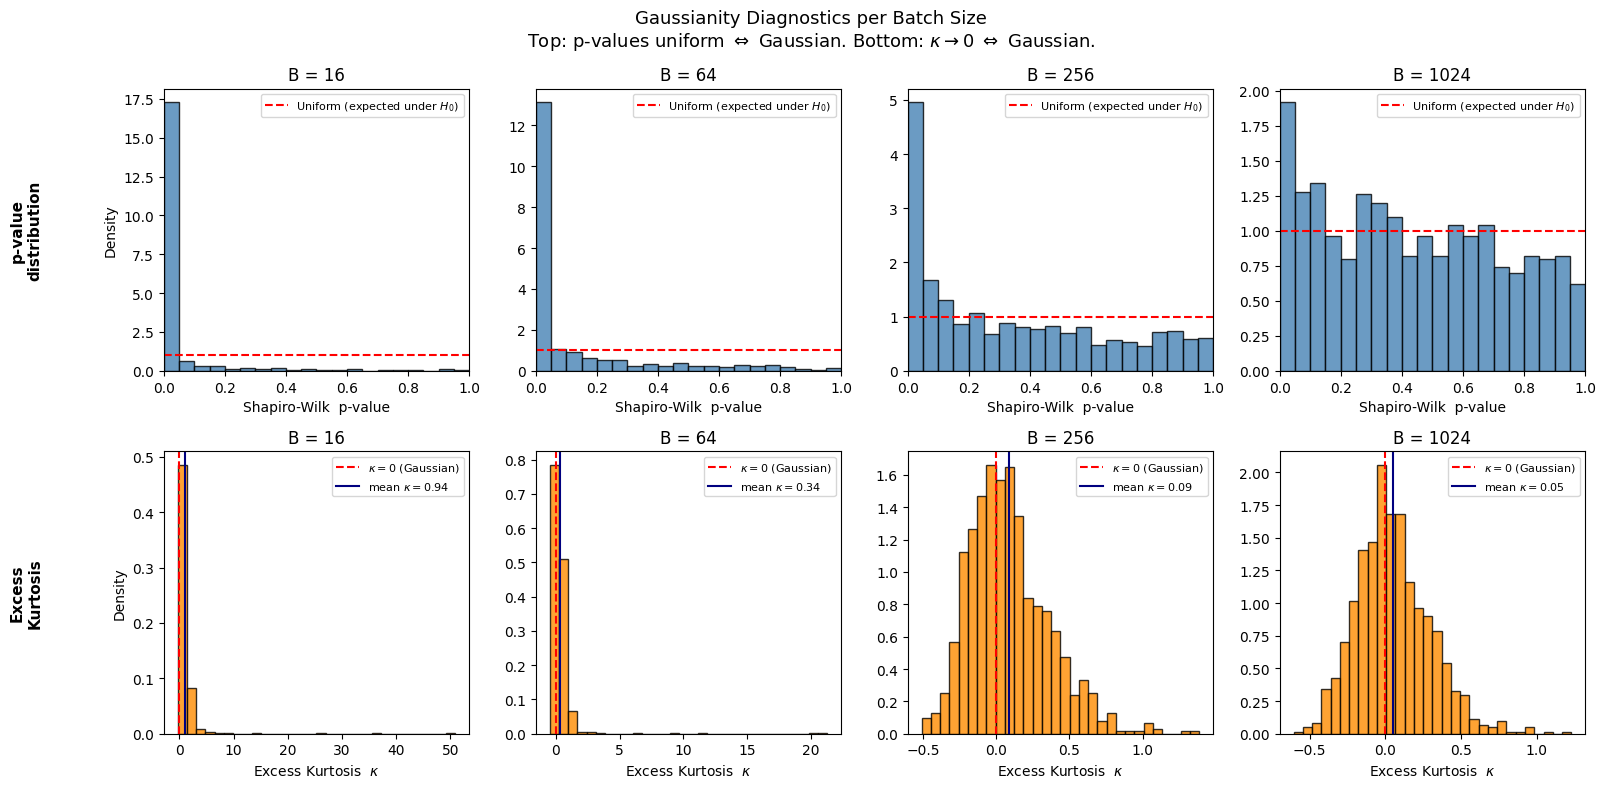

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ── Re-sample the same parameter indices (same seed → reproducible) ──────────
rng_diag = np.random.default_rng(42)

n_cols = len(batch_sizes_to_test)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))
if n_cols == 1:
    axes = axes.reshape(2, 1)

for col, B in enumerate(batch_sizes_to_test):
    noise_matrix = noise_dict[B]
    _, M = noise_matrix.shape
    params_to_test = min(M, max_params_to_test)
    indices = rng_diag.choice(M, size=params_to_test, replace=False)

    p_values  = []
    kurtoses  = []
    for idx in indices:
        col_data = noise_matrix[:, idx]
        _, p = stats.shapiro(col_data)
        p_values.append(p)
        kurtoses.append(stats.kurtosis(col_data, fisher=True))  # excess kurtosis; 0 = Gaussian

    p_values = np.array(p_values)
    kurtoses = np.array(kurtoses)

    # ── Row 0: p-value histogram ──────────────────────────────────────────────
    ax0 = axes[0, col]
    ax0.hist(p_values, bins=20, range=(0, 1), color='steelblue',
             edgecolor='black', density=True, alpha=0.8)
    ax0.axhline(1.0, color='red', linestyle='--', linewidth=1.5,
                label='Uniform (expected under $H_0$)')
    ax0.set_title(f'B = {B}', fontsize=12)
    ax0.set_xlabel('Shapiro-Wilk  p-value', fontsize=10)
    ax0.set_xlim(0, 1)
    if col == 0:
        ax0.set_ylabel('Density', fontsize=10)
    ax0.legend(fontsize=8)

    # ── Row 1: excess kurtosis histogram ─────────────────────────────────────
    ax1 = axes[1, col]
    ax1.hist(kurtoses, bins=30, color='darkorange',
             edgecolor='black', density=True, alpha=0.8)
    ax1.axvline(0, color='red', linestyle='--', linewidth=1.5,
                label=r'$\kappa=0$ (Gaussian)')
    mean_k = np.mean(kurtoses)
    ax1.axvline(mean_k, color='navy', linestyle='-', linewidth=1.5,
                label=fr'mean $\kappa={mean_k:.2f}$')
    ax1.set_title(f'B = {B}', fontsize=12)
    ax1.set_xlabel('Excess Kurtosis  $\\kappa$', fontsize=10)
    if col == 0:
        ax1.set_ylabel('Density', fontsize=10)
    ax1.legend(fontsize=8)

# Row labels on the left
axes[0, 0].annotate('p-value\ndistribution', xy=(0, 0.5),
                    xycoords='axes fraction', xytext=(-0.45, 0.5),
                    textcoords='axes fraction', fontsize=11,
                    fontweight='bold', va='center', ha='center',
                    rotation=90)
axes[1, 0].annotate('Excess\nKurtosis', xy=(0, 0.5),
                    xycoords='axes fraction', xytext=(-0.45, 0.5),
                    textcoords='axes fraction', fontsize=11,
                    fontweight='bold', va='center', ha='center',
                    rotation=90)

fig.suptitle('Gaussianity Diagnostics per Batch Size\n'
             r'Top: p-values uniform $\Leftrightarrow$ Gaussian. '
             r'Bottom: $\kappa\to 0$ $\Leftrightarrow$ Gaussian.',
             fontsize=13)
plt.tight_layout()
plt.savefig("Gaussianity_Diagnostics.png", dpi=300)
plt.show()
